# LightPred Result Analysis

本 notebook 用于整理 LightPred 的训练日志、预测结果和与传统基线方法的对比结果，作为论文第四章与附录的图表来源。

建议先运行：
`python -m src.lightpred.evaluate_lightpred`


In [19]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DATA_ROOT = Path('data/kepler')
MODEL_DIR = DATA_ROOT / 'models'
LOG_PATH = MODEL_DIR / 'lightpred_train_log.csv'
PRED_PATH = MODEL_DIR / 'lightpred_predictions.csv'
SUMMARY_PATH = MODEL_DIR / 'lightpred_eval_summary.csv'
COMPARE_PATH = MODEL_DIR / 'lightpred_baseline_compare_val.csv'

PALETTE = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#64B5CD', '#DD8452', '#937860']
sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.08,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.linestyle': '--',
        'grid.alpha': 0.28,
    },
)
plt.rcParams['figure.dpi'] = 110


In [20]:
if not LOG_PATH.exists():
    raise FileNotFoundError(f'Missing training log: {LOG_PATH}')
if not PRED_PATH.exists():
    raise FileNotFoundError(
        f'Missing prediction CSV: {PRED_PATH}. Please run `python -m src.lightpred.evaluate_lightpred` first.'
    )
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f'Missing summary CSV: {SUMMARY_PATH}. Please run `python -m src.lightpred.evaluate_lightpred` first.'
    )

train_df = pd.read_csv(LOG_PATH)
pred_df = pd.read_csv(PRED_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)
compare_df = pd.read_csv(COMPARE_PATH) if COMPARE_PATH.exists() else pd.DataFrame()

print('train_log:', train_df.shape)
print('predictions:', pred_df.shape)
print('summary:', summary_df.shape)
print('compare:', compare_df.shape)


train_log: (44, 5)
predictions: (1818, 11)
summary: (3, 9)
compare: (5, 10)


## 训练过程曲线

先看训练/验证损失和 MAE 的变化，用于判断模型是否收敛、是否出现明显过拟合。


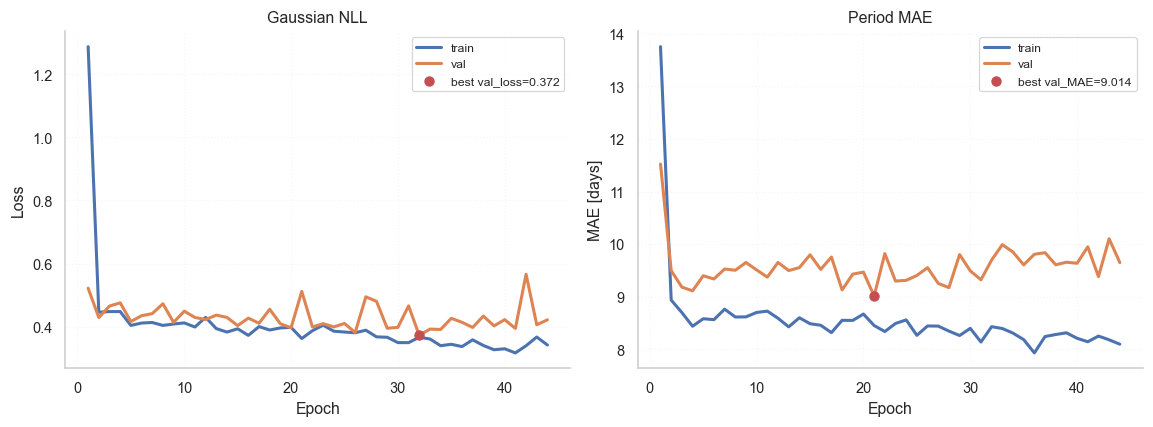

In [21]:
best_loss_idx = train_df['val_loss'].idxmin()
best_mae_idx = train_df['val_mae'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0))

axes[0].plot(train_df['epoch'], train_df['train_loss'], label='train', linewidth=2)
axes[0].plot(train_df['epoch'], train_df['val_loss'], label='val', linewidth=2)
axes[0].scatter(
    train_df.loc[best_loss_idx, 'epoch'],
    train_df.loc[best_loss_idx, 'val_loss'],
    color=PALETTE[2],
    s=36,
    zorder=3,
    label=f"best val_loss={train_df.loc[best_loss_idx, 'val_loss']:.3f}",
)
axes[0].set_title('Gaussian NLL')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(frameon=True, fontsize=8)
axes[0].grid(alpha=0.18, linestyle=':')

axes[1].plot(train_df['epoch'], train_df['train_mae'], label='train', linewidth=2)
axes[1].plot(train_df['epoch'], train_df['val_mae'], label='val', linewidth=2)
axes[1].scatter(
    train_df.loc[best_mae_idx, 'epoch'],
    train_df.loc[best_mae_idx, 'val_mae'],
    color=PALETTE[2],
    s=36,
    zorder=3,
    label=f"best val_MAE={train_df.loc[best_mae_idx, 'val_mae']:.3f}",
)
axes[1].set_title('Period MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE [days]')
axes[1].legend(frameon=True, fontsize=8)
axes[1].grid(alpha=0.18, linestyle=':')

plt.tight_layout()
plt.show()


## 汇总指标表

给出全体样本、训练子集和验证子集上的 LightPred 指标汇总。


In [22]:
summary_df.round(4)


,subset,N,MAE,RMSE,MedianAbsErr,Bias,MedianBias,Frac(<10%),Frac(<20%)
0,all,909,7.9543,9.7649,7.1756,-2.3788,-1.6529,0.1089,0.2178
1,train,819,7.8045,9.6024,6.9681,-2.2351,-1.4677,0.1099,0.2222
2,val,90,9.3178,11.1357,8.3906,-3.6862,-3.5079,0.1000,0.1778


## 验证集预测对照图

下面的图最适合直接放在论文第四章中：它们展示了验证集上的预测一致性、误差分布和不确定性信息。


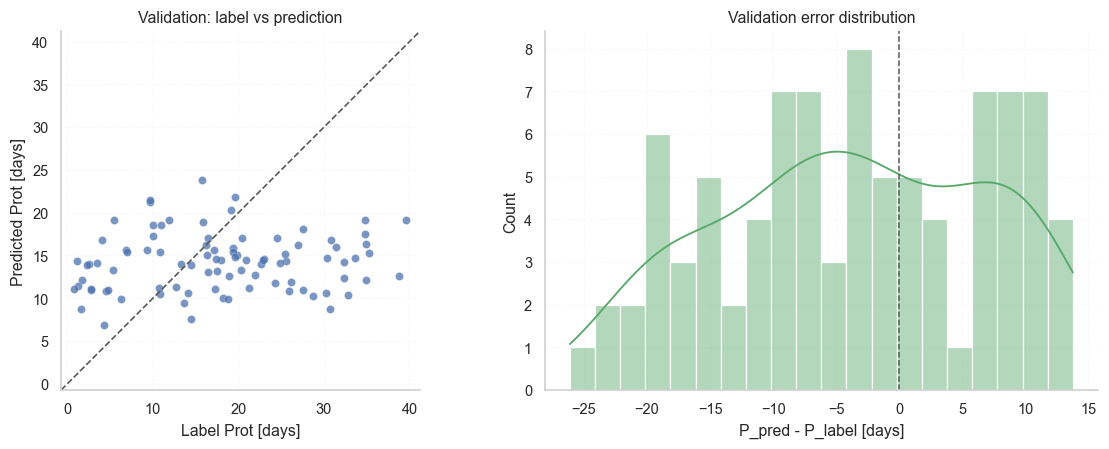

In [23]:
val_df = pred_df[pred_df['split'] == 'val'].copy()
if val_df.empty:
    raise RuntimeError('Validation prediction rows are empty.')

lims = [
    min(val_df['true_period'].min(), val_df['pred_period'].min()),
    max(val_df['true_period'].max(), val_df['pred_period'].max()),
]
pad = 0.04 * (lims[1] - lims[0] if lims[1] > lims[0] else 1.0)
lims = [lims[0] - pad, lims[1] + pad]

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))

sns.scatterplot(
    data=val_df,
    x='true_period',
    y='pred_period',
    s=28,
    alpha=0.75,
    linewidth=0.2,
    edgecolor='white',
    color=PALETTE[0],
    ax=axes[0],
)
axes[0].plot(lims, lims, linestyle='--', color='0.35', linewidth=1.1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect('equal', 'box')
axes[0].set_xlabel('Label Prot [days]')
axes[0].set_ylabel('Predicted Prot [days]')
axes[0].set_title('Validation: label vs prediction')
axes[0].grid(alpha=0.18, linestyle=':')

sns.histplot(
    val_df['pred_period'] - val_df['true_period'],
    bins=20,
    kde=True,
    color=PALETTE[1],
    alpha=0.45,
    ax=axes[1],
)
axes[1].axvline(0.0, linestyle='--', color='0.35', linewidth=1.0)
axes[1].set_xlabel('P_pred - P_label [days]')
axes[1].set_ylabel('Count')
axes[1].set_title('Validation error distribution')
axes[1].grid(alpha=0.18, linestyle=':')

plt.tight_layout()
plt.show()


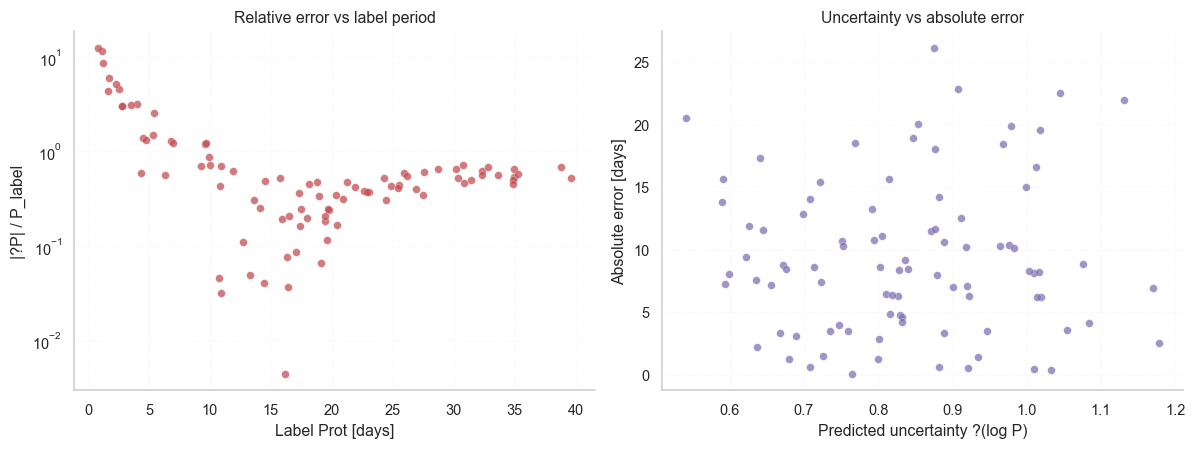

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

sns.scatterplot(
    data=val_df,
    x='true_period',
    y='rel_err',
    s=26,
    alpha=0.75,
    linewidth=0.2,
    edgecolor='white',
    color=PALETTE[2],
    ax=axes[0],
)
axes[0].set_yscale('log')
axes[0].set_xlabel('Label Prot [days]')
axes[0].set_ylabel('|?P| / P_label')
axes[0].set_title('Relative error vs label period')
axes[0].grid(alpha=0.18, linestyle=':')

sns.scatterplot(
    data=val_df,
    x='sigma_log_period',
    y='abs_err',
    s=26,
    alpha=0.75,
    linewidth=0.2,
    edgecolor='white',
    color=PALETTE[3],
    ax=axes[1],
)
axes[1].set_xlabel('Predicted uncertainty ?(log P)')
axes[1].set_ylabel('Absolute error [days]')
axes[1].set_title('Uncertainty vs absolute error')
axes[1].grid(alpha=0.18, linestyle=':')

plt.tight_layout()
plt.show()


## 与传统基线方法的验证集对比

如果评估脚本同时找到了 `baseline_periods_ls_acf.csv`，这里会直接展示 LightPred 与 LS / ACF / GPS / QP-GP 在同一验证子集上的误差指标比较。


In [25]:
if compare_df.empty:
    print('Baseline comparison CSV not found. Run evaluate_lightpred.py with baseline CSV available.')
else:
    compare_df.round(4)


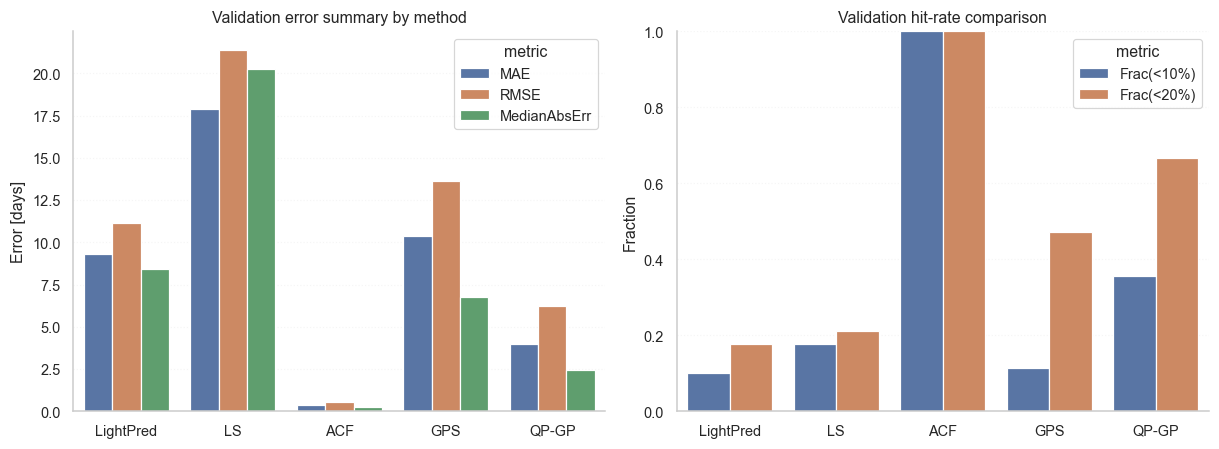

In [26]:
if not compare_df.empty:
    plot_df = compare_df.melt(
        id_vars='method',
        value_vars=['MAE', 'RMSE', 'MedianAbsErr'],
        var_name='metric',
        value_name='days',
    )

    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))

    sns.barplot(data=plot_df, x='method', y='days', hue='metric', ax=axes[0])
    axes[0].set_title('Validation error summary by method')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Error [days]')
    axes[0].grid(axis='y', alpha=0.18, linestyle=':')

    frac_df = compare_df.melt(
        id_vars='method',
        value_vars=['Frac(<10%)', 'Frac(<20%)'],
        var_name='metric',
        value_name='ratio',
    )
    sns.barplot(data=frac_df, x='method', y='ratio', hue='metric', ax=axes[1])
    axes[1].set_title('Validation hit-rate comparison')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Fraction')
    axes[1].set_ylim(0, 1)
    axes[1].grid(axis='y', alpha=0.18, linestyle=':')

    plt.tight_layout()
    plt.show()


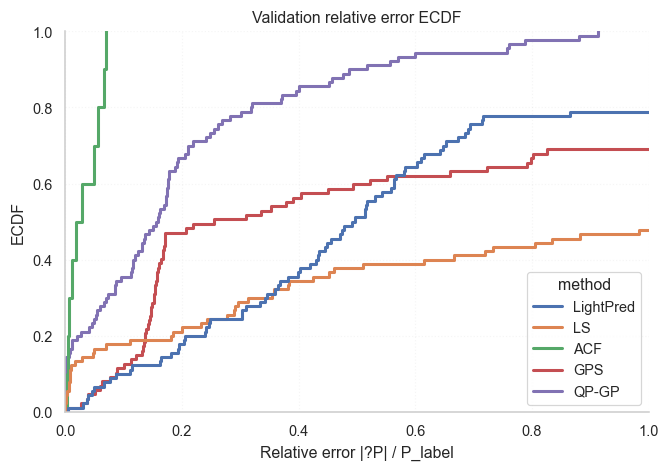

In [27]:
if not compare_df.empty:
    baseline_pred = pd.read_csv(DATA_ROOT / 'baseline_periods_ls_acf.csv')
    merged = val_df[['kic', 'true_period', 'pred_period', 'rel_err']].merge(baseline_pred, on='kic', how='inner')

    ecdf_rows = []
    ecdf_rows.append(pd.DataFrame({'method': 'LightPred', 'rel_err': merged['rel_err']}))
    for name, col in [('LS', 'prot_ls'), ('ACF', 'prot_acf'), ('GPS', 'prot_gps'), ('QP-GP', 'prot_qpgp')]:
        if col in merged.columns:
            tmp = merged[['true_period', col]].replace([np.inf, -np.inf], np.nan).dropna()
            if not tmp.empty:
                rel = (tmp[col] - tmp['true_period']).abs() / tmp['true_period']
                ecdf_rows.append(pd.DataFrame({'method': name, 'rel_err': rel}))

    ecdf_df = pd.concat(ecdf_rows, ignore_index=True)
    plt.figure(figsize=(6.2, 4.4))
    sns.ecdfplot(data=ecdf_df, x='rel_err', hue='method', linewidth=2)
    plt.xlim(0, min(ecdf_df['rel_err'].quantile(0.95) * 1.1, 1.0))
    plt.xlabel('Relative error |?P| / P_label')
    plt.ylabel('ECDF')
    plt.title('Validation relative error ECDF')
    plt.grid(alpha=0.18, linestyle=':')
    plt.tight_layout()
    plt.show()
